# 2 建模方法

如引言部分所述，本文将开展相关实验，以降低响应曲面带来的不确定性，同时需要借助统计建模方法对各类不确定性进行量化。本文采用的核心方法为高斯过程（GP）回归。在介绍该方法前，我们先梳理若干联系紧密的建模理论：数值分析领域中的多项式模型与径向基函数，以及地质统计学领域的克里金法。后文将会说明，上述所有建模方法最终可推导出高度相似的求解结果；而理解这些看似迥异的理论思路，能够为我们提供看待问题的全新视角，对后续章节的研究具有重要价值。为阐述相关理论，首先假设数据不受随机误差干扰，即式 (1.1) 中不存在误差项 $\epsilon$。该情形常见于确定性计算机模型，例如图 1.1 中的密度泛函理论（DFT）模型、图 1.3 中的加工仿真模型。由于不存在随机误差，我们需要构建能够对数据进行插值的模型，相关内容将在 2.1 节展开讨论。随后，在 2.2 节中，我们对这类插值模型进行拓展，使其能够处理含噪声的数据。

## 2.1 插值

本节讨论的插值模型将在本书第二部分关于计算机试验的内容中得到广泛应用。

### 2.1.1 多项式插值

考虑一维测试函数 $$h(x)=\frac{\sin(10\pi x)}{1 + 64(x - 0.25)^2} + x^2,\quad x\in[0,1]\tag{2.1}$$ 我们假定实验人员不知道该函数的具体形式，仅能够获取部分数据。设通过开展 $n=10$ 次实验生成数据，实验采样方案为区间 $[0,1]$ 上等间隔选取 10 个采样点。图 2.1 左图绘制了该测试函数（黑色虚线）以及数据集 $\{(x_i, y_i)\}_{i=1}^{10}$（蓝色圆点）。

> **图 2.1** 采用 10 个等距设计点（左图）与 10 个切比雪夫设计点（右图）进行多项式插值。

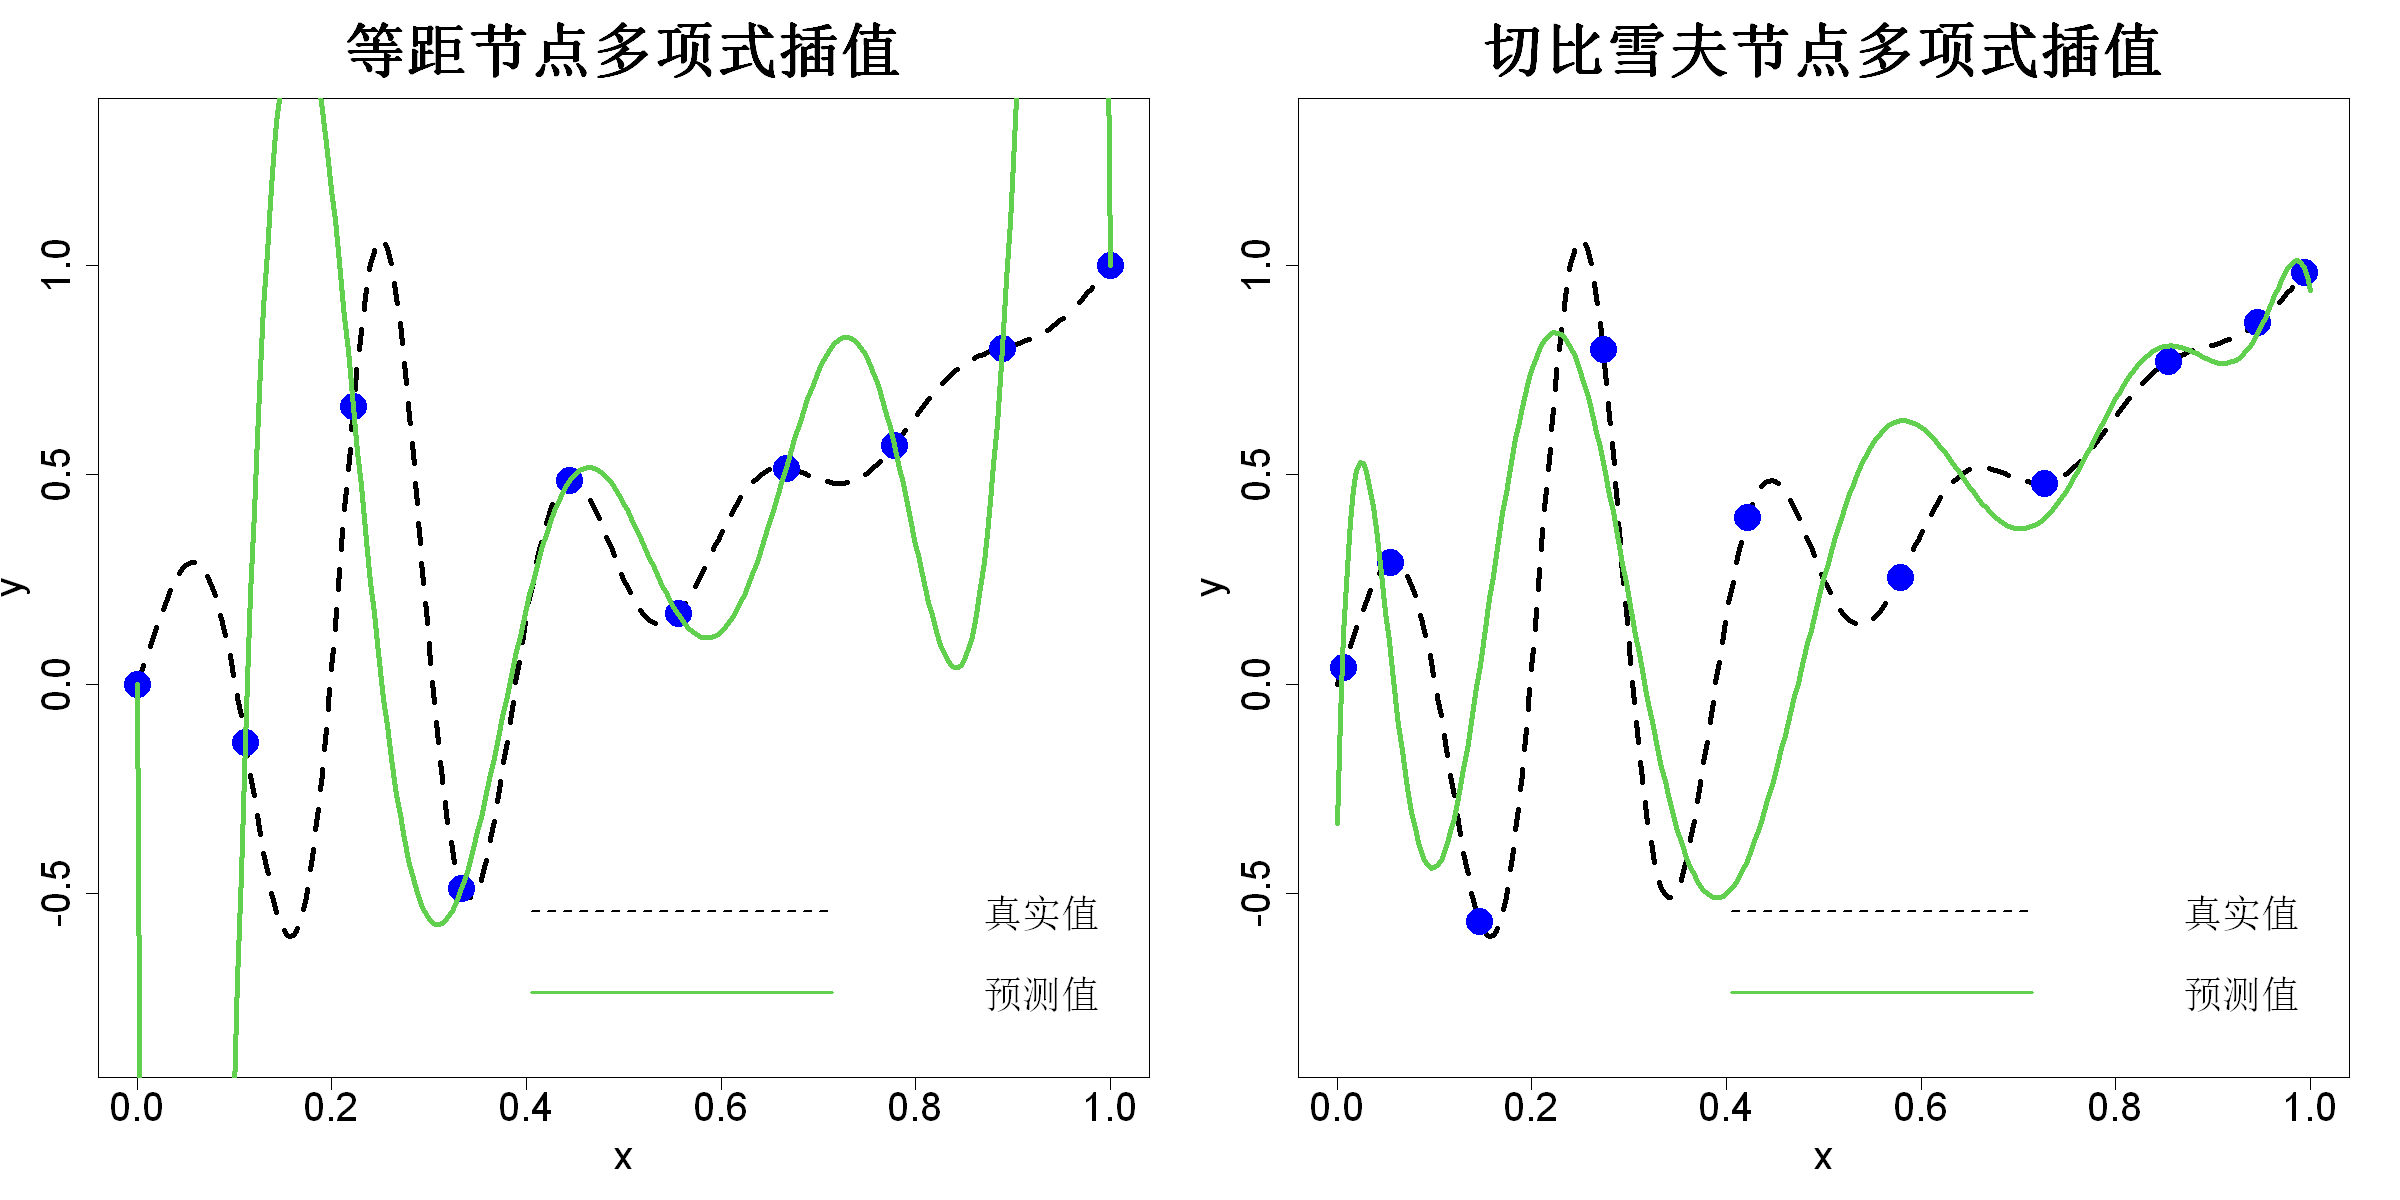

In [ ]:
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=seq(0,1,length=301)
true=f(test)

plot(test,true,type="l",xlab="x",ylab="y",lwd=4,lty=2,ylim=c(min(true)-.25,max(true)+.25),main="等距节点多项式插值",cex.main=3,cex.lab=2,cex.axis=2)
n=10
D=((1:n)-1)/(n-1)
y=f(D)
points(cbind(D,y),pch=16,cex=3,col="blue")
library(pracma)
p=polyfit(D,y,n-1)
yhat=polyval(p,test)
lines(test,yhat,col=3,lwd=4)
legend(.25,-.35,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(2,3),bty="n",cex=2)

plot(test,true,type="l",xlab="x",ylab="y",lwd=4,lty=2,col=1,ylim=c(min(true)-.25,max(true)+.25),main="切比雪夫节点多项式插值",cex.main=3,cex.lab=2,cex.axis=2)
d=cos(pi*((1:n)-.5)/n)
D=(d+1)/2
y=f(D)
points(cbind(D,y),pch=16,cex=3,col="blue")
yhat=chebApprox(test,f,0,1,n)
lines(test,yhat,col=3,lwd=4)
legend(.25,-.35,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(2,3),bty="n",cex=2)
par(mfrow=c(1,1))

我们可以使用 $(n-1)$ 次多项式对 $n$ 个数据点进行插值：$$y = \beta_0 + \beta_1x + \dots + \beta_{n-1}x^{n-1}\tag{2.2}$$ 一维多项式插值存在显式求解公式，例如拉格朗日插值公式。但为了将插值公式与本章介绍的其他方法建立联系，我们将采用另一种推导思路。

首先，将式 (2.2) 中的多项式改写为 $$y = \beta_0R_0(x) + \beta_1R_1(x) + \dots + \beta_{n-1}R_{n-1}(x)\tag{2.3}$$ 其中 $R_i(x)$ 为 $i$ 次多项式，且规定 $R_0(x):=1$。例如，当 $x\in[-1,1]$ 时，可选取切比雪夫多项式：$R_1(x)=x$，$R_2(x)=2x^2-1$，$R_3(x)=4x^3-3x$，以此类推。切比雪夫多项式还有另一种表达形式：$R_i(x) = \cos\left(i\cos^{-1}(x)\right)$。选用式 (2.2) 或是式 (2.3) 均可，但后者具备更好的数值稳定性。接下来，为实现插值，需满足 $$\sum_{j=0}^{n-1}\beta_jR_j(x_i) = y_i,\quad i=1,\dots,n$$ 采用矩阵记号，该方程组可写作 $$\boldsymbol{R}\boldsymbol{\beta} = \boldsymbol{y}$$ 式中 $\boldsymbol{\beta} = (\beta_0,\dots,\beta_{n-1})'$，$\boldsymbol{y} = (y_1,\dots,y_n)'$；$\boldsymbol{R}$ 为 $n\times n$ 矩阵，其第 $i$ 行第 $j$ 列元素为 $R_j(x_i)$。注意本书通篇遵循如下约定：粗体字母用于表示向量与矩阵。

若 $\boldsymbol{R}$ 为非奇异矩阵，则可求得唯一解 $$\hat{\boldsymbol{\beta}} = \boldsymbol{R}^{-1}\boldsymbol{y}$$ 由此得到多项式插值函数 $\hat{y}(x) = \boldsymbol{r}(x)'\hat{\boldsymbol{\beta}}$，其中 $\boldsymbol{r}(x) = (R_0(x), \dots, R_{n-1}(x))'$。因此，$$\hat{y}(x) = \boldsymbol{r}(x)'\boldsymbol{R}^{-1}\boldsymbol{y} \tag{2.4}$$ 该插值函数在图 2.1 中以绿色实线绘制。可以看到，正如插值函数应具备的性质，曲线经过全部 10 个样本点；但遗憾的是，除中间区间外，该函数对真实函数的近似效果较差。插值曲线在两端出现剧烈震荡，这是高次多项式插值中一个众所周知的问题，即龙格现象。

我们可以通过优化实验设计来克服龙格现象，提升多项式插值效果。设 $h_{n-1}(x)$ 为 $(n-1)$ 次多项式，对区间 $x_i\in[-1,1] \ (i=1,\dots,n)$ 上的数据 $\{(x_i, h(x_i))\}_{i=1}^n$ 进行插值。若 $h(x)$ 至少存在 $n$ 阶可导，则其预测误差可写为（希尔德布兰德，1987，第 63 页）：$$h(x) - h_{n-1}(x) = \frac{h^{(n)}(\xi)}{n!}\prod_{i=1}^n (x-x_i)$$ 其中存在 $\xi\in[-1,1]$，$h^{(n)}(x)$ 代表 $h(x)$ 的 $n$ 阶导数。由此可以得到绝对误差上界：$$|h(x)-h_{n-1}(x)| \le \frac{1}{n!}\max_{\xi}\left|h^{(n)}(\xi)\right|\left|\prod_{i=1}^n (x-x_i)\right|$$ 切比雪夫多项式具备一个优良性质：经过适当缩放后，它能够使所有 $n$ 次多项式的最大绝对值最小化。因此，令 $$\prod_{i=1}^n (x-x_i) = \frac{1}{2^{n-1}}\cos\left(n\cos^{-1}(x)\right)$$ 即可最小化绝对误差上界，式中分母引入缩放常数 $2^{n-1}$，用于保证等式两侧首项系数匹配。由该式能够直接推出，节点 $x_i$ 应当取切比雪夫多项式的零点（也称切比雪夫节点）。通过求解方程 $$\cos\left(n\cos^{-1}(x_i)\right)=0$$ 可得节点表达式： $$x_i=\cos\left(\frac{\pi(i-0.5)}{n}\right),\quad i=1,\dots,n \tag{2.5}$$

图 2.1 右侧面板绘制了采用切比雪夫节点得到的 10 个试验设计点及其对应的函数求值结果（节点通过变换 $x \leftarrow (x + 1)/2$ 由区间 $[-1,1]$ 缩放至区间 $[0,1]$）。可以观察到，相较于等距设计点，这类设计点更多向区间两端边界聚集。图中同时以绿色实线给出插值函数，该插值函数能够较好逼近真实函数，相比左侧面板中的前一种插值方案实现了显著改进。该实例直观体现了试验设计的重要性！

尽管在一维问题中采用切比雪夫节点作为多项式插值的试验设计方案效果良好，但当存在多个输入变量时，多项式插值会出现问题。以图 2.2 左图所示的 $2^2$ 全因子设计（吴与滨田，2021）为例。可以通过对各变量上的两点设计 $(0,1)$ 进行张量积运算 $(0,1)\otimes(0,1)$ 得到该 $2^2$ 设计。我们可以通过拟合如下形式的多项式模型实现插值：$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_1x_2$$ 式中，$x_1x_2$ 项代表两个输入变量之间的交互效应。该多项式中的各项同样可以通过类似的乘积形式表示：$(1, x_1)\otimes(1, x_2)=(1, x_1, x_2, x_1x_2)$。接下来观察同一幅图右侧中两个采样点经过微小扰动后的情形。此时构造能够插值这四个点的多项式不再直观。事实上，插值多项式可能不唯一，需要借助专用算法求解（贝茨等人，2003）。

> **图 2.2** 左图为 $2^2$ 试验设计，右图为将该设计中两个采样点施加扰动后得到的设计。

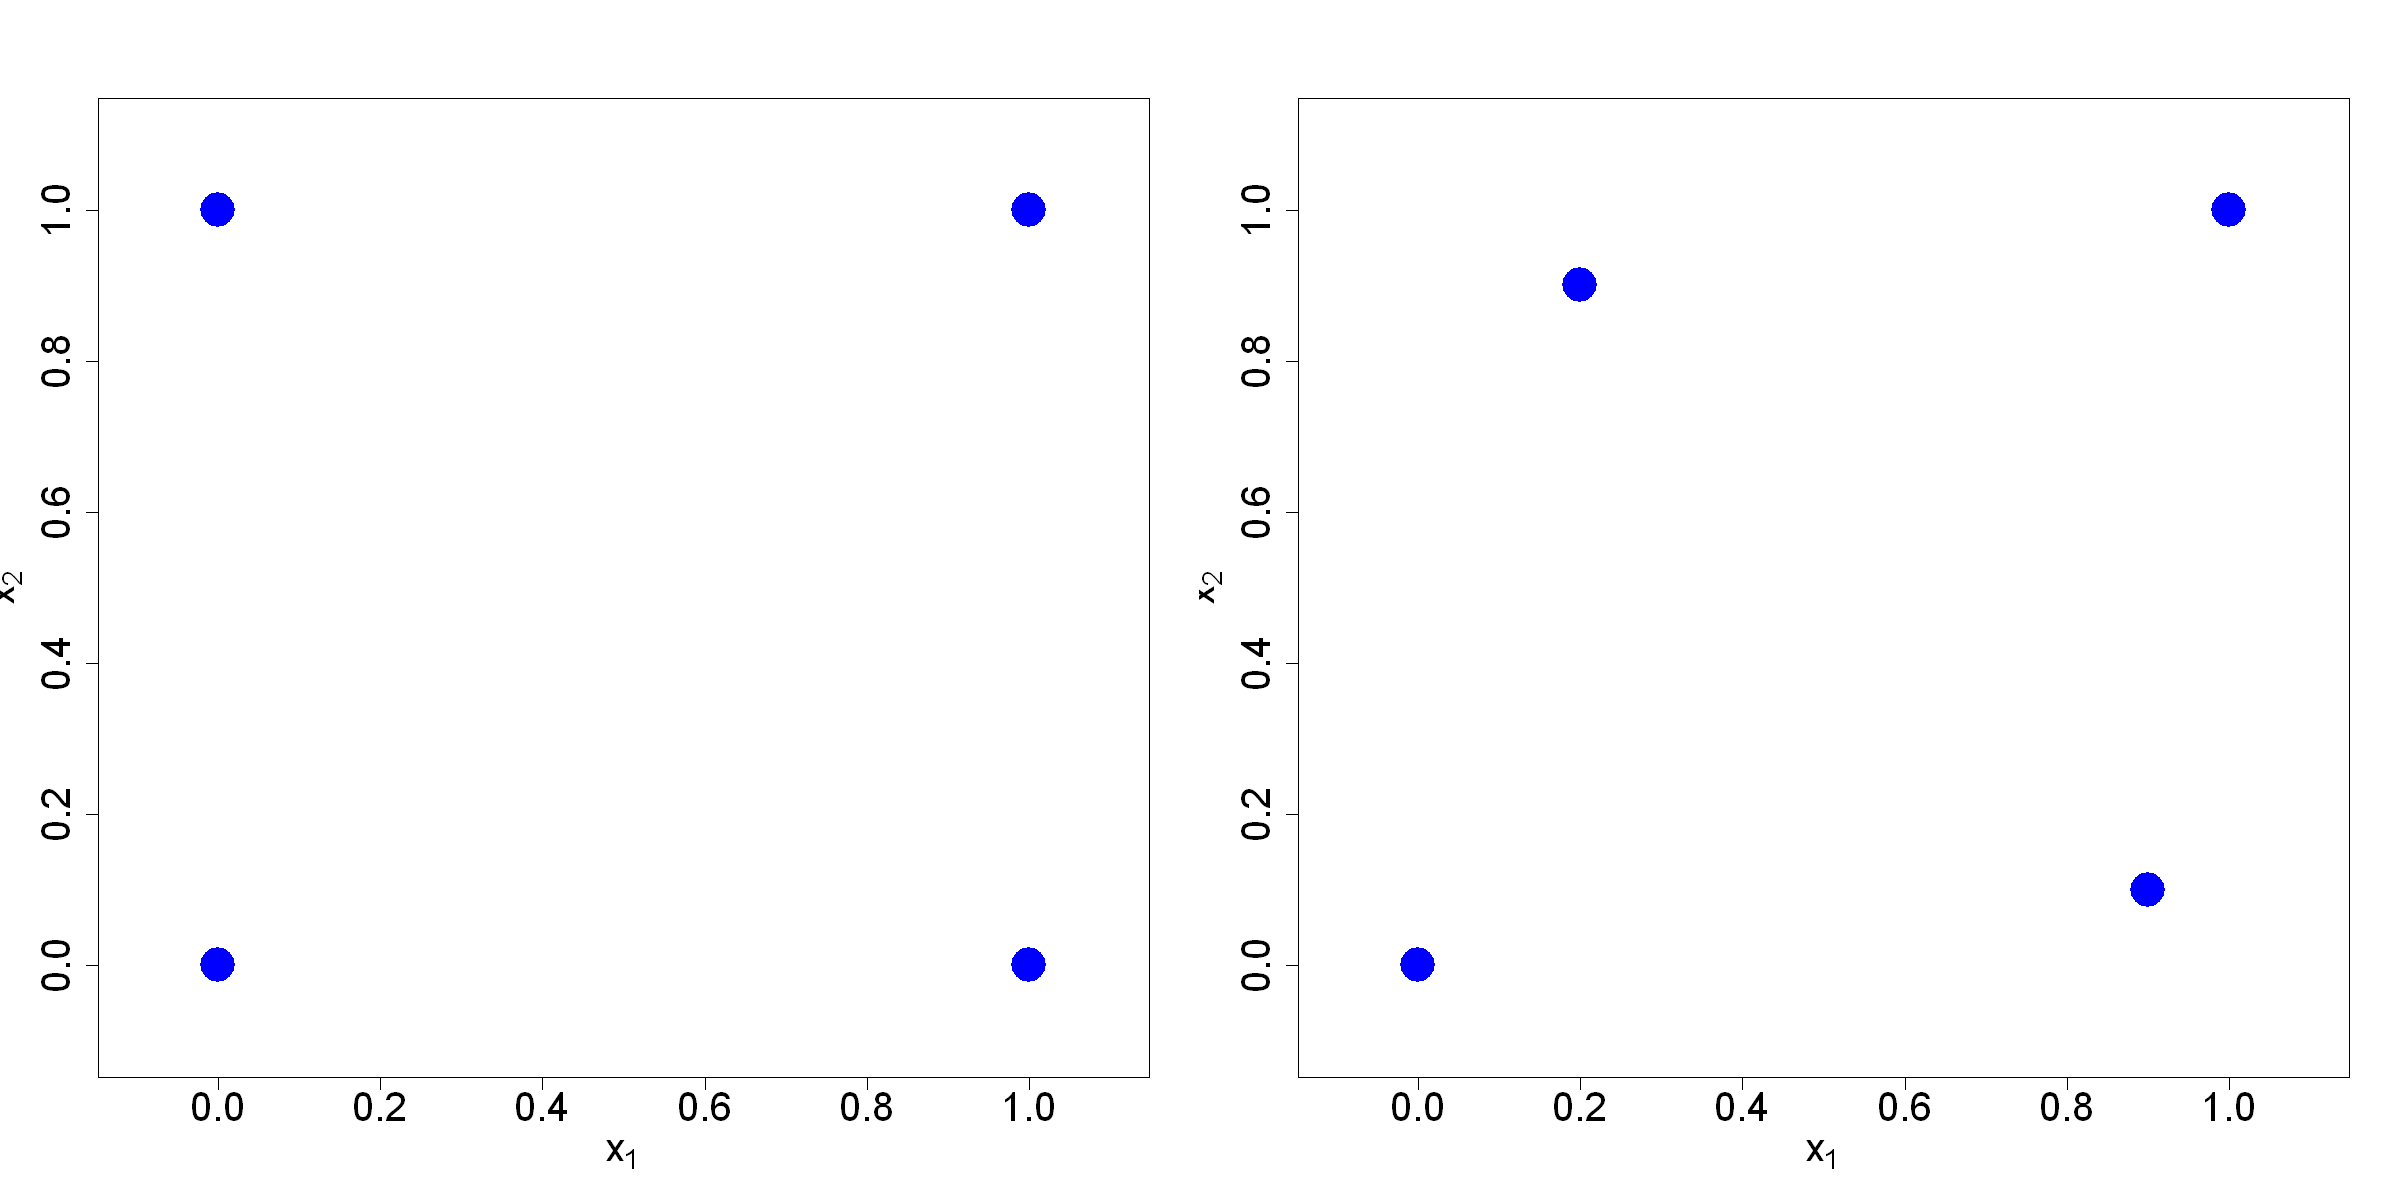

In [ ]:
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
D=matrix(c(0,0,0,1,1,0,1,1),nrow=4,ncol=2,byrow=TRUE)
plot(D,pch=16,cex=4,col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2)

D=matrix(c(0,0,.2,.9,.9,.1,1,1),nrow=4,ncol=2,byrow=TRUE)
plot(D,pch=16,cex=4,col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2)
par(mfrow=c(1,1))

针对高维问题使用多项式模型的一种方法是：利用切比雪夫节点在每个维度上采样 $n$ 个点，再构建全因子试验设计。但该方法需要开展 $n^p$ 次试验，当 $p$ 数值较大时并不具备可行性。我们可以借助部分因子试验设计（第 8 章）或者稀疏网格（斯莫利亚克，1963；修，2010；普拉姆利，2014）减少试验次数，然而这类试验设计以及对应的多项式模型无法适配序贯设计（第 7 章）。在序贯试验中，我们可能希望在空间的特定区域增补采样点，不受试验设计特定结构的约束。这就需要适用于散乱数据、灵活性更强的插值方法。下一节将要介绍的径向基函数便是此类方法之一。